# NB07 — Figures, preregistered readings, write-up inputs

**Plan §11 (deliverables), revised §9 (readings). Budget: 2.5 h. No GPU — a CPU pod, or your
laptop against a synced copy of `runs/`.**

Everything here is read on the **normalized** scale: the fraction of the activation's
contribution an arm retains, `(score − floor) / C.CONTRIBUTION_SPAN`, with the floor measured
in NB03 §1 at matched `N`. Revised §4.2 is blunt about why — rotation can only destroy what
the activation contributes, which the paper's own ablation bounds at ~4 exact-match points, so
raw score gaps understate the effect by roughly 15× and the raw thresholds in v1 of the
preregistration were literally unreachable. Raw numbers are printed alongside throughout,
because a reader comparing against the paper's tables needs them.

**The denominator is a constant (0.041), not `reference − floor`.** That per-N span is an
estimate whose own 95% CI contains zero at every `N` in the sweep and which is negative at
N=256, so the ratio it produced had no finite mean — see `se_config.CONTRIBUTION_SPAN` and
the `fixed-denominator-2026-08-24` entry in `preregistration.json`, which records the change
as post-hoc. Two consequences for everything below:

- **1.0 is the paper's whole activation contribution, not our unrotated arm.** `R-id` is no
  longer pinned to 1.0; where it lands is a measurement, and it is reported as one.
- **`destroyed` is `retained(R-id) − retained(R-Q)`**, what rotation removed — not
  `1 − retained`, which was only correct while `R-id` sat at 1 by construction.

Assembles everything into the deliverables list:

3. sweep curves per metric, identity vs Q, faceted by capacity arm
4. capacity-recovery plot: score vs input-map rank at fixed `N`
5. ridge-projector comparison against the self-explainer
6. invariance-gate numbers reported, not buried in a log
7. honest failure log
8. a stated position on which row of §7.2 the results landed on

The readings are applied **mechanically** from `preregistration.json`, which was written in
NB00 before any results existed. That is the point of having written it.


In [1]:
# --- dependencies -----------------------------------------------------------
# A RunPod image ships torch built against the pod's own driver, so nothing here may
# replace it: se_env pins the installed torch as a pip constraint and installs only what
# is missing or below the floor these notebooks need — including bitsandbytes, which Colab
# had preinstalled and RunPod images do not (se_common asks for paged_adamw_8bit).
# Safe to re-run: a no-op on a warm pod.
import os
import sys

# `se/` holds the shared modules: se_env, se_config, rotate, se_common. Clone this repo
# onto the pod's volume (/workspace/self_explainer) so it survives the pod.
REPO_DIR = os.environ.get("SE_REPO_DIR", "/workspace/self_explainer")
if not os.path.isdir(os.path.join(REPO_DIR, "se")):
    REPO_DIR = os.path.abspath(".." if os.path.isdir("../se") else ".")
sys.path.insert(0, os.path.join(REPO_DIR, "se"))

import se_env

se_env.ensure_deps()


dependencies: already satisfied (torch 2.8.0+cu128, transformers 5.15.1, peft 0.20.0, trl 1.10.0, bitsandbytes 0.50.1)


{}

In [2]:
# --- environment ------------------------------------------------------------
# Caches and outputs go on the pod's volume, never the container disk: /workspace is what
# survives a stopped or terminated pod, and the 8B checkpoint alone is 16 GB. HF_TOKEN comes
# from the pod template's environment or <volume>/.hf_token — there is no prompt to answer,
# because a preempted pod restarts with nobody watching.
#
# Reads finished runs and draws figures: a CPU pod, or your laptop.
env = se_env.bootstrap(repo_dir=REPO_DIR, gpu="none", min_vram_gb=0)

import se_config as C


RUNPOD ENVIRONMENT
host    : RunPod pod xx6cyd3zbg973t  |  python 3.12.3
gpu     : 1 x NVIDIA RTX PRO 6000 Blackwell Server Edition  |  95 GiB  |  bf16 yes
torch   : 2.8.0+cu128  (CUDA 12.8)
stack   : transformers 5.15.1 · peft 0.20.0 · trl 1.10.0 · datasets 5.0.1 · accelerate 1.14.0 · bitsandbytes 0.50.1
repo    : /workspace/self_explainer
volume  : /workspace  (own mount, 350841 GiB free)
hf cache: /workspace/.cache/huggingface/
outputs : /workspace/self_explainer
hf token: none


In [3]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import se_common as S

prereg = json.load(open(f"{C.REPORTS_DIR}/preregistration.json"))
metric = prereg["primary_metric"]
TH = prereg["thresholds"]
print(f"preregistered {prereg['written_at']} (v{prereg.get('version', 1)}); "
      f"primary metric = {metric}")
if prereg.get("version", 1) < 2:
    print("!! this is a pre-audit preregistration: its thresholds are raw-scale and it has no")
    print("   row for the rank-artifact hypothesis. Readings below that reference normalized")
    print("   thresholds will fall back to the raw ones where they exist.")

df = S.collect_results("patching")
print(f"\n{len(df)} patching runs found")
print(df.groupby(["rotation", "capacity", "init"]).n_train.apply(list).to_string())

# --- the no-activation floor: the denominator of every normalized number -----
floor_path = f"{C.REPORTS_DIR}/no_activation_floor.csv"
floors = {}
if os.path.exists(floor_path):
    fdf = pd.read_csv(floor_path)
    floors = {m: dict(zip(fdf.n_train.astype(int), fdf[m]))
              for m in ("exact_match", "has_changed_f1", "content_match") if m in fdf}
    print(f"\nno-activation floor, {metric}: "
          + ", ".join(f"N={n}:{v:.3f}" for n, v in sorted(floors[metric].items())))
else:
    print("\n!! no no_activation_floor.csv — run NB03 §1. Normalized readings will be skipped,")
    print("   and the raw ones understate every effect by roughly the range ratio.")

SELF_TAG = C.EXPLAINER_MODEL_ID.split("/")[-1]


def floor_at(n, m=None):
    """The measured floor at N, nearest measured N in log space if that one is missing."""
    m = m or metric
    table = floors.get(m, {})
    if not table:
        return None
    n = int(n)
    return table.get(n) or table[min(table, key=lambda k: abs(np.log2(k) - np.log2(n)))]


def score_at(rotation, n, capacity="Cfull", init="identity", explainer_tag=SELF_TAG, m=None):
    """One cell of the grid, averaged over seeds. Defaults to the self-explainer: NB05 puts a
    second explainer into the same tree, and averaging across them would be meaningless."""
    m = m or metric
    sub = df[(df.rotation == rotation) & (df.capacity == capacity)
             & (df.init == init) & (df.n_train == n)]
    if "explainer_tag" in df and explainer_tag is not None:
        sub = sub[sub.explainer_tag == explainer_tag]
    return float(sub[m].mean()) if len(sub) else None


def retained_at(rotation, n, capacity="Cfull", init="identity", m=None):
    """Fraction of the activation's contribution this cell keeps, on the fixed scale.

    The denominator is the constant `C.CONTRIBUTION_SPAN` (the paper's Table 5 `- activation`
    span, 4.1 exact-match points), not this N's `score(Cfull, R-id) - floor`. The per-N span
    is an estimate whose own 95% CI contains zero at every N in the sweep and which is
    negative at N=256; the ratio it produced was a Fieller statistic with no finite mean
    (se_config.CONTRIBUTION_SPAN, prereg_threshold_justification.md §1.1).

    Consequence for every reading below: **1.0 is the paper's whole activation contribution,
    not our unrotated arm.** `retained_at("identity", n)` is now a measurement rather than
    1.0 by construction, and any rule phrased as "recovers X of what R-id got" must subtract
    the two retained values rather than compare one of them to 1.
    """
    m = m or metric
    v, fl = score_at(rotation, n, capacity, init, m=m), floor_at(n, m)
    if v is None or fl is None:
        return None
    return S.fraction_retained(v, fl)


preregistered 2026-08-18T01:15:10 (v2); primary metric = exact_match

148 patching runs found
rotation  capacity    init      
Q         C0          identity      [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
                      ridge                                                     [nan]
          C128        identity      [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
          C512        identity      [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
          C8          identity      [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
          Cfull       identity      [16384.0, 16384.0, 16384.0, 8192.0, 8192.0, 81...
          Cfull-rand  orthogonal    [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
          Oracle      oracle        [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
identity  C0          identity      [16384.0, 2048.0, 2048.0, 2048.0, 512.0, 512.0...
                      ridge                                                     [nan]
          C12

## Figure 1 — sweep curves, faceted by capacity arm

Top row raw with the measured floor drawn in, bottom row normalized. `C0` is the paper's own
patching configuration and `C128` its rank cap (Appendix F.1, F.3), so those facets are the
paper's setup under rotation rather than ours — label them that way in the caption.


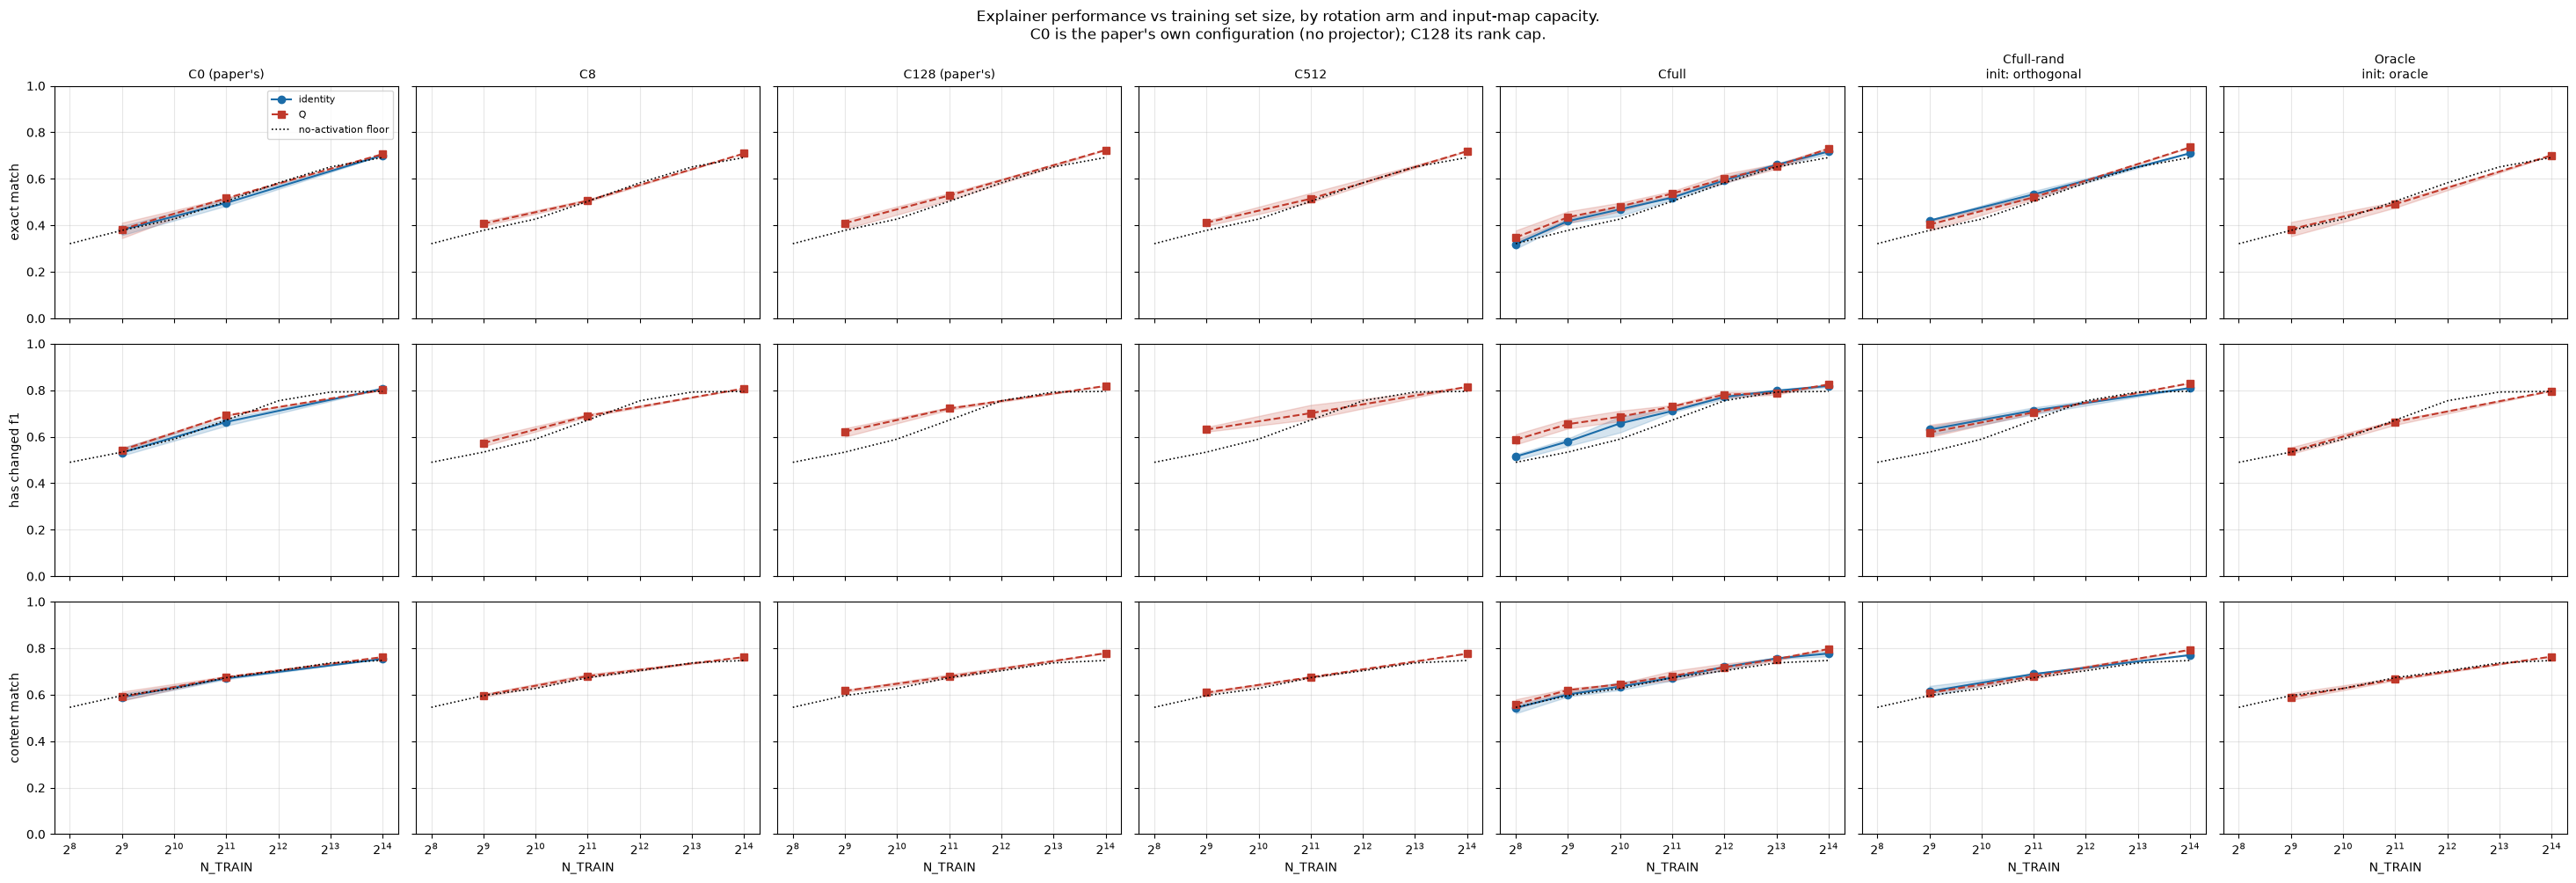

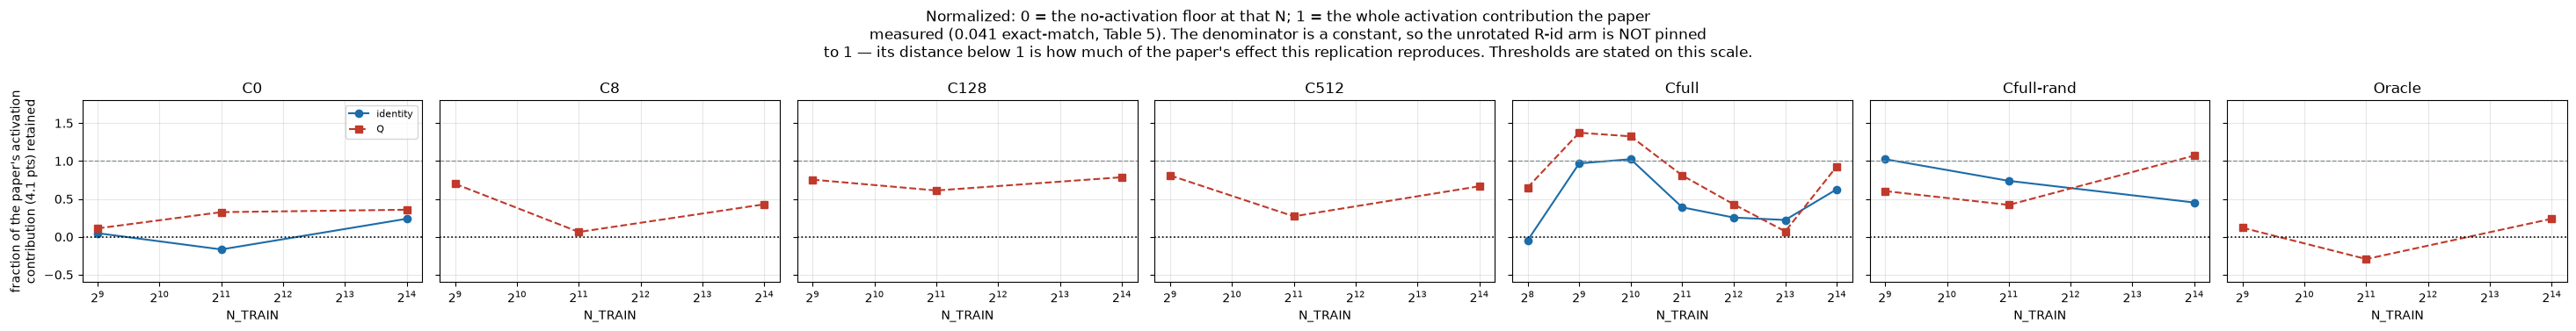

In [13]:
METRICS = ["exact_match", "has_changed_f1", "content_match"]
STYLE = {"identity": dict(marker="o", color="#1b6ca8"),
         "Q": dict(marker="s", color="#c0392b", linestyle="--"),
         "Qscaled": dict(marker="^", color="#8e44ad", linestyle="-.")}
FILL = {"identity": "#1b6ca8", "Q": "#c0392b", "Qscaled": "#8e44ad"}

caps = [c for c in C.CAPACITIES if c in set(df.capacity)]

# Each capacity has its OWN init: Cfull-rand trains from a random orthogonal map
# ("orthogonal") and Oracle from the frozen Q^T ("oracle"), while every ladder rung is
# "identity" (C.CAPACITY_DEFAULT_INIT). Filtering every facet on init == "identity" drew
# the Cfull-rand and Oracle panels with no lines at all — the runs exist, the filter
# excluded them.
def init_for(cap):
    return C.CAPACITY_DEFAULT_INIT.get(cap, "identity")
fig, axes = plt.subplots(len(METRICS), len(caps),
                         figsize=(4.2 * len(caps), 3.4 * len(METRICS)),
                         squeeze=False, sharey="row", sharex=True)

for i, m in enumerate(METRICS):
    for j, cap in enumerate(caps):
        ax = axes[i][j]
        for arm, style in STYLE.items():
            sub = df[(df.capacity == cap) & (df.rotation == arm)
                     & (df.init == init_for(cap))].sort_values("n_train")
            if "explainer_tag" in df:
                sub = sub[sub.explainer_tag == SELF_TAG]
            sub = sub[sub.n_train.notna()]
            if len(sub):
                # collapse seed replicates into a mean line and a min/max band
                g = sub.groupby("n_train")[m].agg(["mean", "min", "max"]).sort_index()
                ax.plot(g.index, g["mean"], label=arm, **style)
                ax.fill_between(g.index, g["min"], g["max"], color=FILL[arm], alpha=0.18)
        if floors.get(m):
            fl = pd.Series(floors[m]).sort_index()
            ax.plot(fl.index, fl.values, color="black", linestyle=":", linewidth=1.2,
                    label="no-activation floor")
        ax.set_xscale("log", base=2)
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        if i == 0:
            paper = " (paper's)" if cap in ("C0", "C128") else ""
            ini = init_for(cap)
            ax.set_title(f"{cap}{paper}" + ("" if ini == "identity" else f"\ninit: {ini}"),
                         fontsize=10)
        if i == len(METRICS) - 1:
            ax.set_xlabel("N_TRAIN")
        if j == 0:
            ax.set_ylabel(m.replace("_", " "))
axes[0][0].legend(fontsize=8)
fig.suptitle("Explainer performance vs training set size, by rotation arm and input-map "
             "capacity.\nC0 is the paper's own configuration (no projector); C128 its "
             "rank cap.")
fig.tight_layout()
fig.savefig(f"{C.FIGURES_DIR}/sweep_by_capacity.png", dpi=150)
plt.show()

# --- the same thing on the scale the readings are stated in ------------------
if floors.get(metric):
    fig, axes = plt.subplots(1, len(caps), figsize=(4.2 * len(caps), 3.8),
                             squeeze=False, sharey=True)
    for j, cap in enumerate(caps):
        ax = axes[0][j]
        for arm, style in STYLE.items():
            sub = df[(df.capacity == cap) & (df.rotation == arm)
                     & (df.init == init_for(cap))]
            if "explainer_tag" in df:
                sub = sub[sub.explainer_tag == SELF_TAG]
            sub = sub[sub.n_train.notna()]
            if not len(sub):
                continue
            g = sub.groupby("n_train")[metric].mean().sort_index()
            y = [retained_at(arm, int(n), cap, init_for(cap)) for n in g.index]
            ax.plot(g.index, y, label=arm, **style)
        ax.axhline(0, color="black", linestyle=":", linewidth=1.2)
        # 1.0 is the paper's contribution, not our reference arm — grey, not the R-id blue
        ax.axhline(1, color="#7f8c8d", linestyle="--", linewidth=0.9)
        ax.set_xscale("log", base=2)
        ax.set_ylim(-0.6, 1.8)
        ax.grid(alpha=0.3)
        ax.set_title(cap)
        ax.set_xlabel("N_TRAIN")
    axes[0][0].set_ylabel("fraction of the paper's activation\ncontribution (4.1 pts) retained")
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"Normalized: 0 = the no-activation floor at that N; 1 = the whole activation "
                 f"contribution the paper\nmeasured ({C.CONTRIBUTION_SPAN:.3f} exact-match, "
                 f"Table 5). The denominator is a constant, so the unrotated R-id arm is NOT "
                 f"pinned\nto 1 — its distance below 1 is how much of the paper's effect this "
                 f"replication reproduces. Thresholds are stated on this scale.")
    fig.tight_layout()
    fig.savefig(f"{C.FIGURES_DIR}/sweep_normalized.png", dpi=150)
    plt.show()


## Figure 2 — capacity recovery


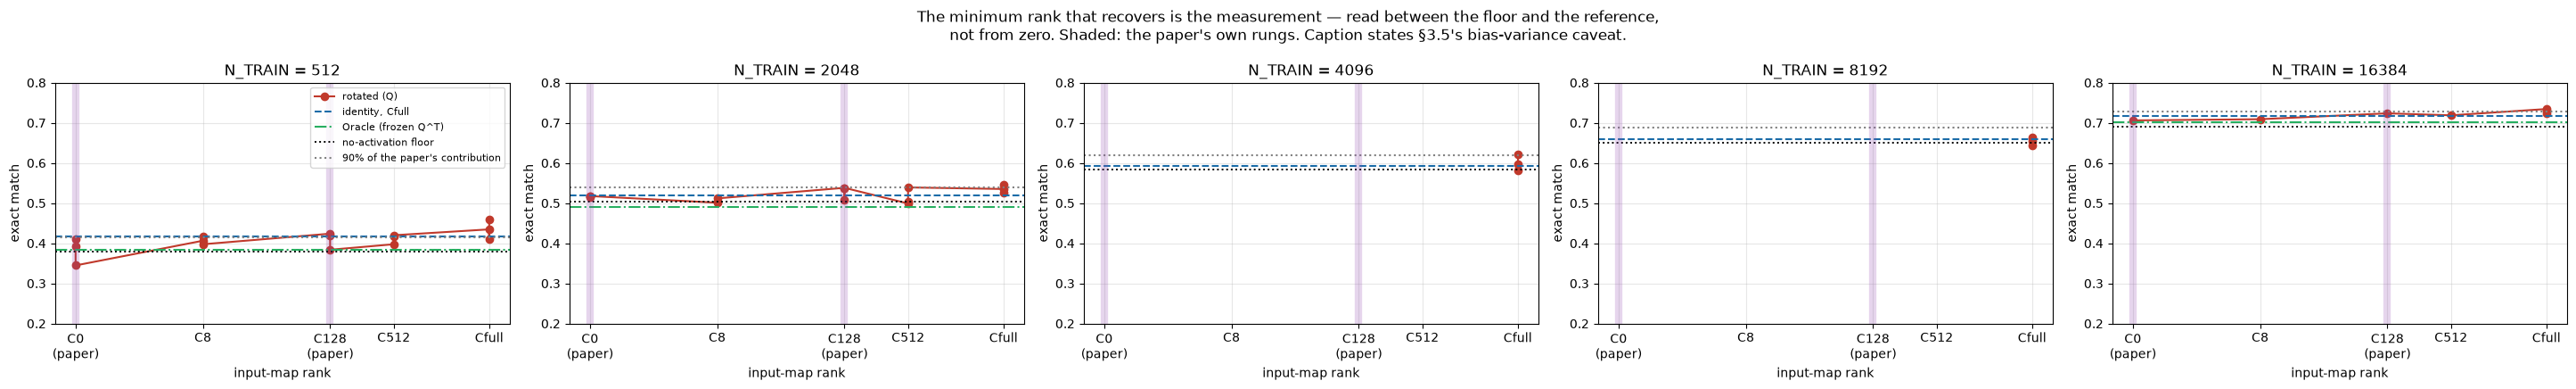

In [12]:
RANK_X = {"C0": 0.5, "C8": 8, "C128": 128, "C512": 512, "Cfull": 4096}
PAPER_RUNGS = {"C0", "C128"}

ns = sorted(set(df[df.capacity.isin(["C8", "C128", "C512"])].n_train.dropna()))
if ns:
    fig, axes = plt.subplots(1, len(ns), figsize=(5.8 * len(ns), 4.4), squeeze=False)
    for ax, n in zip(axes[0], ns):
        sub = df[(df.rotation == "Q") & (df.n_train == n) & (df.init == "identity")]
        if "explainer_tag" in df:
            sub = sub[sub.explainer_tag == SELF_TAG]
        sub = sub.assign(x=sub.capacity.map(RANK_X)).sort_values("x")
        ax.plot(sub.x, sub[metric], marker="o", color="#c0392b", label="rotated (Q)")
        ref = score_at("identity", n)
        if ref is not None:
            ax.axhline(ref, color="#1b6ca8", linestyle="--", label="identity, Cfull")
        oracle = score_at("Q", n, capacity="Oracle", init="oracle")
        if oracle is not None:
            ax.axhline(oracle, color="#27ae60", linestyle="-.", label="Oracle (frozen Q^T)")
        fl = floor_at(n)
        if fl is not None:
            ax.axhline(fl, color="black", linestyle=":", linewidth=1.4,
                       label="no-activation floor")
            # against the CONSTANT span, so this line sits at the same height above the
            # floor at every N; previously it tracked `ref - fl`, which is 0.040 at N=512
            # and 0.009 at N=8192, making "90% recovery" mean something different per panel
            ax.axhline(fl + TH["recovery_fraction"] * C.CONTRIBUTION_SPAN, color="grey",
                       linestyle=":",
                       label=f"{TH['recovery_fraction']:.0%} of the paper's contribution")
        for cap in PAPER_RUNGS:
            ax.axvline(RANK_X[cap], color="#8e44ad", alpha=0.22, linewidth=6)
        ax.set_xscale("log", base=2)
        ax.set_xticks(list(RANK_X.values()))
        ax.set_xticklabels([f"{k}\n(paper)" if k in PAPER_RUNGS else k for k in RANK_X])
        ax.set_xlabel("input-map rank")
        ax.set_ylabel(metric.replace("_", " "))
        ax.set_title(f"N_TRAIN = {int(n)}")
        ax.set_ylim(0.2, 0.8)
        ax.grid(alpha=0.3)
    axes[0][0].legend(fontsize=8)
    fig.suptitle("The minimum rank that recovers is the measurement — read between the floor and "
                 "the reference,\nnot from zero. Shaded: the paper's own rungs. Caption states "
                 "§3.5's bias-variance caveat.")
    fig.tight_layout()
    fig.savefig(f"{C.FIGURES_DIR}/capacity_recovery_nb07.png", dpi=150)
    plt.show()
else:
    print("no ladder runs found — run NB04")


## Figure 3 — the alternative recipe, and the rank-artifact test

Two claims in one panel. The recipe claim is `P-ridge-frozen` against the self-explainer: can
a closed-form fit replace per-target training? The audit claim is `P-rand` against
`P-rand-full`: the paper's cross-model condition is a random projector under a rank-128 cap
(F.3), so if lifting the cap alone closes most of the distance to `P-ridge`, its
random-vs-pretrained gap is largely about rank rather than about alignment.


In [ ]:
recipe_path = f"{C.REPORTS_DIR}/ridge_recipe.csv"
if os.path.exists(recipe_path):
    recipe = pd.read_csv(recipe_path)

    # One panel per N, and every arm in a panel is read at THAT N against THAT N's own
    # reference and floor. The previous version averaged each arm over all N_TRAIN but drew
    # the reference bar and the floor line at max(N_TRAIN), so low-N cross-model bars were
    # plotted against a high-N self-explainer: P-rand and P-rand-full have no N=16384 run at
    # all, and the "N = 16384" title asserted a comparison that is not in ridge_recipe.csv.
    TRAINED = ["P-rand", "P-rand-full", "P-ridge · R-id", "P-ridge · R-Q"]
    FROZEN = [l for l in recipe.label.unique() if "frozen" in l]
    COLOR = {"P-rand": "#e67e22", "P-rand-full": "#e67e22",
             "P-ridge · R-id": "#7f8c8d", "P-ridge · R-Q": "#7f8c8d", "self": "#1b6ca8"}

    def ref_seeds(n):
        """The self-explainer reference cell at N, so the bar can carry its own seed spread."""
        sub = df[(df.rotation == "identity") & (df.capacity == "Cfull")
                 & (df.init == "identity") & (df.n_train == n)]
        if "explainer_tag" in df:
            sub = sub[sub.explainer_tag == SELF_TAG]
        return sub[metric].tolist()

    trained = recipe[recipe.label.isin(TRAINED)].dropna(subset=["n_train"])
    ns = sorted(trained.n_train.unique())

    fig = plt.figure(figsize=(5.2 * len(ns), 5.6))
    gs = fig.add_gridspec(2, len(ns), height_ratios=[3.0, 0.9], hspace=0.75, wspace=0.42,
                          top=0.80, bottom=0.09, left=0.10, right=0.98)

    for j, n in enumerate(ns):
        ax = fig.add_subplot(gs[0, j])
        sub = trained[trained.n_train == n]
        labels, values, errs, colors, seeds = [], [], [], [], []

        rs = ref_seeds(n)
        ref = score_at("identity", n)
        if ref is not None:
            labels.append("E_self · Cfull · R-id\n(reference)")
            values.append(ref)
            errs.append(float(np.std(rs, ddof=1)) if len(rs) > 1 else 0.0)
            colors.append(COLOR["self"])
            seeds.append(len(rs))
        for lab in TRAINED:
            g = sub[sub.label == lab]
            if g.empty:
                continue
            labels.append(lab)
            values.append(g[metric].mean())
            errs.append(g[metric].std() if len(g) > 1 else 0.0)
            colors.append(COLOR.get(lab, "#7f8c8d"))
            seeds.append(len(g))

        y = np.arange(len(labels))
        ax.barh(y, values, xerr=errs, color=colors, capsize=3,
                error_kw=dict(elinewidth=1.1, ecolor="#333333"))
        for i, (v, s) in enumerate(zip(values, seeds)):
            ax.text(v + max(errs[i], 0) + 0.02, i,
                    f"{v:.3f}" + (f" (n={s})" if s > 1 else " (1 seed)"),
                    va="center", fontsize=8.5)
        fl = floor_at(n)
        if fl is not None:
            ax.axvline(fl, color="black", linestyle=":", linewidth=1.4)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=8.5)
        ax.invert_yaxis()
        ax.set_xlim(0, 1.0)
        ax.set_ylim(len(labels) - 0.3, -0.6)
        ax.set_xlabel(metric.replace("_", " "), fontsize=9)
        missing = [l for l in ("P-rand", "P-rand-full") if l not in set(sub.label)]
        note = f"\n(no {' / '.join(missing)} run at this N)" if missing else ""
        floor_txt = f"   ·   no-activation floor (dotted) {fl:.3f}" if fl is not None else ""
        ax.set_title(f"N_TRAIN = {int(n)}{floor_txt}{note}", fontsize=9.5, pad=8)
        ax.grid(alpha=0.3, axis="x")

    # The frozen arms are never trained on the target, so they have no N and cannot sit in
    # an N panel. They get their own strip rather than a bar in an arbitrary one.
    if FROZEN:
        axf = fig.add_subplot(gs[1, :])
        fz = recipe[recipe.label.isin(FROZEN)]
        yf = np.arange(len(fz))
        axf.barh(yf, fz[metric].values, color="#c0392b")
        for i, (_, row) in enumerate(fz.iterrows()):
            axf.text(0.015, i,
                     f"{row[metric]:.3f}   unparseable rate {row.unparseable_rate:.2f}",
                     va="center", fontsize=9)
        axf.set_yticks(yf)
        axf.set_yticklabels(fz.label.values, fontsize=8.5)
        axf.invert_yaxis()
        axf.set_xlim(0, 1)
        axf.set_xlabel(metric.replace("_", " "), fontsize=9)
        axf.set_title("No per-target training (N-independent): the frozen ridge recipe "
                      "produced no parseable output", fontsize=9.5, pad=8)
        axf.grid(alpha=0.3, axis="x")

    fig.suptitle("Closed-form ridge vs the self-explainer, and the rank cap vs the projector "
                 "init\nEach panel compares arms at a MATCHED N against that N's own "
                 "reference and floor", fontsize=11.5, y=0.965)
    fig.savefig(f"{C.FIGURES_DIR}/ridge_recipe.png", dpi=150)
    plt.show()

    agg = recipe.groupby("label")[metric].mean().to_dict()
    if {"P-rand", "P-rand-full"} <= set(agg):
        # same guard as NB05 §5: the P-rand -> P-ridge gap is a measured difference, so it
        # gets its CI checked before anything is divided by it.
        # NOTE: this pools seeds across N, which is what verdicts.json records. The per-N
        # version is in reports/rank_artifact.json and is the one to quote alongside the
        # figure above, since the figure is now read at matched N.
        def _seeds(lbl):
            return [float(v) for v in recipe[recipe.label == lbl][metric]]
        cl = S.closure_with_ci(_seeds("P-rand"), _seeds("P-rand-full"),
                               _seeds("P-ridge · R-id"))
        if cl.get("gap_se") is not None:
            print(f"P-ridge - P-rand gap (pooled over N): {cl['gap']:+.4f} "
                  f"+/- {cl['gap_se']:.4f} se, "
                  f"95% CI [{cl['gap_ci95'][0]:+.4f}, {cl['gap_ci95'][1]:+.4f}]")
        if cl.get("closure") is not None:
            ci = cl.get("closure_ci95")
            print(f"rank-cap closure: {cl['closure']:+.2f}"
                  + (f" Fieller 95% CI [{ci[0]:+.2f}, {ci[1]:+.2f}]" if ci else "")
                  + f" of the P-rand -> P-ridge gap "
                    f"(threshold {TH.get('rank_artifact_closure', 0.5)})")
        else:
            print(f"rank-cap closure: NOT REPORTED — {cl['note']}")
else:
    print("no ridge results — run NB05")


## The preregistered readings, applied

Each rule from `preregistration.json`, evaluated against the data. No interpretation is added
here that was not committed to in NB00.


In [7]:
ns = sorted(set(df[(df.capacity == "Cfull") & (df.init == "identity")].n_train.dropna()))
gaps, destroyed = {}, {}
for n in ns:
    a, b = score_at("identity", n), score_at("Q", n)
    if a is not None and b is not None:
        gaps[int(n)] = a - b
    # what rotation removed, on the fixed scale. NOT `1 - retained(R-Q)`: that was only
    # correct while R-id sat at exactly 1 by construction, which a constant denominator
    # no longer makes true.
    r_q, r_id = retained_at("Q", int(n)), retained_at("identity", int(n))
    if r_q is not None and r_id is not None:
        destroyed[int(n)] = r_id - r_q

print(f"raw gap = {metric}(R-id) - {metric}(R-Q) at Cfull, and the fraction of the")
print("activation's contribution that rotation destroyed\n")
print(f"{'N':>7} {'raw gap':>10} {'destroyed':>12} {'ret(R-id)':>11} {'ret(R-Q)':>10} "
      f"{'floor':>8} {'reference':>10}")
for n in ns:
    n = int(n)
    fl, ref = floor_at(n), score_at("identity", n)
    ri, rq = retained_at("identity", n), retained_at("Q", n)
    print(f"{n:>7} {gaps.get(n, float('nan')):>10.4f} "
          f"{destroyed.get(n, float('nan')):>12.3f} "
          f"{float('nan') if ri is None else ri:>+11.3f} "
          f"{float('nan') if rq is None else rq:>+10.3f} "
          f"{fl if fl is None else round(fl, 3):>8} {ref if ref is None else round(ref, 3):>10}")
print("\nret(R-id) is a RESULT, not 1.0 by construction: it is the share of the paper's "
      f"{C.CONTRIBUTION_SPAN:.3f}-point\nactivation contribution our unrotated arm reproduces "
      "at each N.")

# paired differences, where NB03 wrote them: the tightest statement this eval size supports
paired_path = f"{C.REPORTS_DIR}/paired_deltas.json"
if os.path.exists(paired_path):
    paired = json.load(open(paired_path))
    print("\npaired (McNemar) R-id vs R-Q on the same eval items:")
    for row in paired:
        lo, hi = row["ci95"]
        excludes = "excludes 0" if lo > 0 or hi < 0 else "includes 0"
        print(f"  N={row['n_train']:>5}: {row['delta']:+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
              f"({excludes})")


raw gap = exact_match(R-id) - exact_match(R-Q) at Cfull, and the fraction of the
activation's contribution that rotation destroyed

      N    raw gap    destroyed   ret(R-id)   ret(R-Q)    floor  reference
    256    -0.0286       -0.699      -0.048     +0.651    0.321      0.319
    512    -0.0166       -0.405      +0.969     +1.374    0.378      0.418
   1024    -0.0124       -0.302      +1.024     +1.326    0.427      0.469
   2048    -0.0173       -0.421      +0.389     +0.810    0.503      0.519
   4096    -0.0072       -0.175      +0.254     +0.429    0.583      0.593
   8192     0.0062        0.151      +0.222     +0.071    0.651       0.66
  16384    -0.0124       -0.302      +0.627     +0.929    0.691      0.717

ret(R-id) is a RESULT, not 1.0 by construction: it is the share of the paper's 0.041-point
activation contribution our unrotated arm reproduces at each N.

paired (McNemar) R-id vs R-Q on the same eval items:
  N=  256: -0.0430  95% CI [-0.0689, -0.0170]  (excludes 0

In [8]:
def band_norm(rotation="Q", capacity="Cfull", init="identity"):
    """Seed band width, expressed on the normalized scale so it can be compared to
    `destroyed`. A band in raw points is not comparable to a threshold in fractions.

    Divides by the constant span. Under the old per-N `ref - fl` the SAME raw band came out
    4x wider at N=8192 than at N=512 purely because the denominator shrank, so "inside the
    band" meant something different at every N — and the band is what `attainable_optimum`
    and `all_inside_band` are read against."""
    sub = df[(df.rotation == rotation) & (df.capacity == capacity) & (df.init == init)]
    if "explainer_tag" in df:
        sub = sub[sub.explainer_tag == SELF_TAG]
    widths = []
    for n, g in sub.groupby("n_train"):
        if len(g) < 2:
            continue
        widths.append((g[metric].max() - g[metric].min()) / C.CONTRIBUTION_SPAN)
    return max(widths) if widths else 0.0


BAND = band_norm()
verdicts, evidence = {}, {}
print(f"seed band on the normalized scale: {BAND:.3f} "
      f"(thresholds: overlap {TH.get('overlap_destroyed')}, "
      f"separated {TH.get('separated_destroyed')})\n")

# --- primary ----------------------------------------------------------------
if destroyed:
    lo, hi = min(destroyed), max(destroyed)
    ov, sep = TH.get("overlap_destroyed", 0.15), TH.get("separated_destroyed", 0.35)
    ret_id = {n: retained_at("identity", n) for n in destroyed}
    ret_q = {n: retained_at("Q", n) for n in destroyed}

    verdicts["no_effect"] = (all(abs(d) < ov for d in destroyed.values())
                             and all(v is not None and v > TH["floor_match_retained"]
                                     for v in ret_q.values()))
    verdicts["sample_efficiency"] = (destroyed[lo] > sep and abs(destroyed[hi]) < ov)
    verdicts["attainable_optimum"] = all(d > max(sep, BAND) for d in destroyed.values())
    verdicts["collapse_to_floor"] = (ret_q.get(hi) is not None
                                     and ret_q[hi] < TH["floor_match_retained"])
    verdicts["below_floor"] = any(v is not None and v < TH["below_floor_retained"]
                                  for v in ret_q.values())
    verdicts["all_inside_band"] = max(abs(d) for d in destroyed.values()) < max(BAND, 1e-9)
    evidence["destroyed"] = destroyed

# the cross-family baseline: the non-self explainer under the paper's own rank-capped
# random projector (P-rand = C128/random, Appendix F.3)
cross_cap, cross_init = C.PROJECTOR_ARMS["P-rand"]
cross = df[(df.capacity == cross_cap) & (df.init == cross_init)
           & (df.rotation == "identity")]
if "explainer_tag" in df:
    cross = cross[cross.explainer_tag != SELF_TAG]
if destroyed and len(cross):
    top = max(destroyed)
    cross_top = cross[cross.n_train == top][metric]
    q_top = score_at("Q", top)
    if len(cross_top) and q_top is not None:
        verdicts["collapse_to_baseline"] = \
            abs(q_top - float(cross_top.mean())) < TH["baseline_match_gap"]
        evidence["cross_baseline"] = float(cross_top.mean())

# do the three metrics agree on the sign of the effect?
signs = set()
for m in METRICS:
    sub = df[(df.capacity == "Cfull") & (df.init == "identity")]
    if "explainer_tag" in df:
        sub = sub[sub.explainer_tag == SELF_TAG]
    p = sub.pivot_table(index="n_train", columns="rotation", values=m, aggfunc="mean")
    if {"identity", "Q"} <= set(p.columns):
        signs.add(int(np.sign((p["identity"] - p["Q"]).mean())))
verdicts["metrics_disagree"] = len(signs) > 1

# --- capacity ---------------------------------------------------------------
ladder_ns = sorted(set(df[df.capacity.isin(["C8", "C128", "C512"])].n_train.dropna()))
if ladder_ns:
    n = int(max(ladder_ns))
    r_c0 = retained_at("Q", n, capacity="C0")
    r_cfull = retained_at("Q", n)
    if r_c0 is not None and r_cfull is not None:
        verdicts["capacity_collapse"] = (r_c0 < TH["floor_match_retained"]
                                         and (r_cfull - r_c0) > TH["separated_destroyed"])
        evidence["retained_C0"] = r_c0
    r_oracle = retained_at("Q", n, capacity="Oracle", init="oracle")
    if r_oracle is not None and r_cfull is not None:
        verdicts["oracle_gap"] = (r_oracle - r_cfull) > TH["separated_destroyed"]
    recovering = [cap for cap in ("C0", "C8", "C128", "C512", "Cfull")
                  if (retained_at("Q", n, capacity=cap) or -9) >= TH["recovery_fraction"]]
    if recovering:
        verdicts["low_rank_recovery"] = recovering[0] in ("C0", "C8")
        evidence["recovery_threshold"] = recovering[0]

rand_ns = sorted(set(df[df.capacity == "Cfull-rand"].n_train.dropna()))
if rand_ns:
    n = int(max(rand_ns))
    d_rand = None
    a = score_at("identity", n, capacity="Cfull-rand", init="orthogonal")
    b = score_at("Q", n, capacity="Cfull-rand", init="orthogonal")
    fl = floor_at(n)
    if None not in (a, b, fl):
        d_rand = (a - b) / C.CONTRIBUTION_SPAN
        if n in destroyed:
            verdicts["cfull_rand_matches"] = \
                abs(d_rand - destroyed[n]) < TH["overlap_destroyed"]
            evidence["destroyed_cfull_rand"] = d_rand

# --- constructive -----------------------------------------------------------
if os.path.exists(recipe_path):
    r = pd.read_csv(recipe_path)
    agg = r.groupby("label")[metric].mean().to_dict()
    self_ref_v = score_at("identity", max(C.N_TRAIN_VALUES))

    frozen = [v for k, v in agg.items() if "frozen" in k and "R-id" in k]
    if frozen and self_ref_v is not None:
        verdicts["ridge_frozen_works"] = abs(frozen[0] - self_ref_v) < TH["overlap_gap_raw"]
    if "P-ridge · R-id" in agg and self_ref_v is not None:
        verdicts["ridge_works"] = \
            abs(agg["P-ridge · R-id"] - self_ref_v) < TH["overlap_gap_raw"]

    if {"P-rand", "P-rand-full"} <= set(agg) and "P-ridge · R-id" in agg:
        cl = S.closure_with_ci(
            [float(v) for v in r[r.label == "P-rand"][metric]],
            [float(v) for v in r[r.label == "P-rand-full"][metric]],
            [float(v) for v in r[r.label == "P-ridge · R-id"][metric]])
        # `rank_artifact` stays None (insufficient data) when the gap it normalizes cannot
        # be told apart from zero — a verdict off a division by noise is worse than no
        # verdict. `rank_not_binding` is a raw-scale claim and is unaffected.
        if cl.get("closure") is not None:
            verdicts["rank_artifact"] = cl["closure"] > TH["rank_artifact_closure"]
            evidence["rank_cap_closure"] = cl["closure"]
            evidence["rank_cap_closure_ci95"] = cl.get("closure_ci95")
        else:
            evidence["rank_cap_closure_unresolvable"] = cl.get("note")
        evidence["rank_gap"] = cl.get("gap")
        evidence["rank_gap_ci95"] = cl.get("gap_ci95")
        verdicts["rank_not_binding"] = \
            abs(agg["P-rand-full"] - agg["P-rand"]) < TH["overlap_gap_raw"]

# --- integrity --------------------------------------------------------------
identity_path = f"{C.REPORTS_DIR}/ridge_rotation_identity.json"
if os.path.exists(identity_path):
    verdicts["ridge_identity_broken"] = \
        json.load(open(identity_path))["max_relative_error"] > TH["ridge_identity_tol"]

exact_path = f"{C.REPORTS_DIR}/exactness_check.json"
if os.path.exists(exact_path):
    verdicts["exactness_failed"] = not json.load(open(exact_path)).get("passed", True)

audit_path = f"{C.REPORTS_DIR}/full_rank_audit.json"
if os.path.exists(audit_path):
    a = json.load(open(audit_path))
    verdicts["full_rank_violated"] = a.get("n_failed", 0) > 0
    evidence["unrecorded_capacity_runs"] = a.get("n_unrecorded", 0)
else:
    wrapped = df.get("input_map_lora_wrapped")
    if wrapped is not None:
        verdicts["full_rank_violated"] = bool(wrapped.fillna(False).any())

ctrl_path = f"{C.REPORTS_DIR}/ablation_control.json"
if os.path.exists(ctrl_path):
    ctrl = json.load(open(ctrl_path))
    verdicts["control_moved"] = not ctrl.get("passed", ctrl.get("generations_identical", True))

# --- print, grouped as §9 groups them ---------------------------------------
print("PREREGISTERED READINGS")
print("=" * 78)
print("Rows are NOT mutually exclusive; more than one may hold. Report every row that does.")
for group in ("primary", "capacity", "constructive", "integrity"):
    rows = [r for r in prereg["readings"] if r.get("group", "primary") == group]
    if not rows:
        continue
    print(f"\n--- {group.upper()} " + "-" * (72 - len(group)))
    for r in rows:
        v = verdicts.get(r["id"])
        if r.get("manual"):
            mark = "   (manual — record by hand)"
        else:
            mark = {True: "-> HOLDS", False: "   no", None: "   (insufficient data)"}[v]
        note = "  [modal outcome]" if r.get("prior") else ""
        print(f"\n{mark}  {r['id']}{note}")
        print(f"    observation: {r['observation']}")
        print(f"    rule       : {r['rule']}")
        if v:
            print(f"    READING    : {r['reading']}")

stops = [k for k in ("below_floor", "ridge_identity_broken", "exactness_failed",
                     "full_rank_violated", "control_moved") if verdicts.get(k)]
if stops:
    print(f"\n!! STOP CONDITIONS FIRED: {stops}. These are bugs, not results — §9 says fix them")
    print("   before reading anything above.")

with open(f"{C.REPORTS_DIR}/verdicts.json", "w") as f:
    json.dump({"gaps": gaps, "destroyed": destroyed, "seed_band_normalized": BAND,
               "verdicts": verdicts, "evidence": evidence,
               "preregistration_version": prereg.get("version", 1)}, f, indent=2, default=S.json_default)


seed band on the normalized scale: 1.239 (thresholds: overlap 0.15, separated 0.35)

PREREGISTERED READINGS
Rows are NOT mutually exclusive; more than one may hold. Report every row that does.

--- PRIMARY -----------------------------------------------------------------

   no  no_effect
    observation: Cfull curves for R-id and R-Q overlap at all N, both above the no-activation floor
    rule       : abs(destroyed) < overlap_destroyed for every N, and both arms clear the floor

   no  sample_efficiency  [modal outcome]
    observation: R-Q separated at low N, converging by the largest N
    rule       : destroyed(min N) > separated_destroyed and abs(destroyed(max N)) < overlap_destroyed

   no  attainable_optimum
    observation: R-Q strictly below R-id at all N, gap larger than the seed band
    rule       : destroyed(N) > max(separated_destroyed, seed band) for every N

   no  collapse_to_floor
    observation: R-Q falls to the no-activation floor
    rule       : retained(R-Q) < 

## Gate numbers, for the write-up

§11.6: *"Invariance-gate numbers reported in the write-up, not buried in a log."*


In [9]:
gate = json.load(open(f"{C.REPORTS_DIR}/invariance_gate.json"))
import rotate as R

# The file holds two kinds of record plus one optional null, so dispatch on the key instead of
# formatting everything as a gate: the *_profile entries are disagreement profiles (no
# thresholds, no mean KL — format_gate_report KeyErrors on them), and debug_float32 is null
# when NB01 ran with RUN_DEBUG_PASS = False.
#
# Verdicts print only for the two records that are tests. fold_only is this run's bf16
# quantization floor, and fold_and_rotate_absolute_bar is the same rotation judged against the
# absolute 1e-4 bar that bf16 re-rounding alone cannot reach (NB01 §0b, plan v2 §5.5) — a
# "FAIL — do not proceed" under either would misreport a number that is doing its job.
MEASUREMENTS = {"fold_only", "fold_and_rotate_absolute_bar"}

for name, rep in gate.items():
    if rep is None:
        print(f"GATE — {name}: not run\n")
        continue
    if name.endswith("_profile"):
        print(R.format_disagreement_profile(rep, f"GATE — {name}"))
    else:
        print(R.format_gate_report(rep, f"GATE — {name}",
                                   show_verdict=name not in MEASUREMENTS))
    print()

print("The gates that decide are fold_and_rotate (floor-relative, 8B, bf16) and debug_float32")
print("(absolute 1e-4, 0.6B, fp32). The other two are printed as measurements: the floor, and")
print("what the same rotation scores against a bar bf16 cannot meet for arithmetic reasons.")

recheck_path = f"{C.REPORTS_DIR}/label_recheck.json"
if os.path.exists(recheck_path):
    rc = json.load(open(recheck_path))
    print(f"\nlabel recheck through the hook path: {rc['agree']}/{rc['checked']} "
          f"= {rc['rate']:.3f} continuation agreement under M_Q")


GATE — fold_only
  sequences / tokens     : 64 / 32728
  mean per-token KL      : 9.135e-04
  max per-token KL       : 3.127e-02
  max |logit delta|      : 8.719e+00
  top-1 agreement        : 0.98378

GATE — fold_only_profile
  tokens / top-1 flips   : 32728 / 541 (agreement 0.98347)
  flip ref top-2 gap     : median 0.0000, p90 0.1250, max 0.3750
  flips where ref top-1 is still the rotated model's 2nd choice : 0.85582
  agreement on decided tokens (gap > 1) : 1.00000  (0/17987 flipped)
  flip rate by reference top-2 logit gap:
         [0, 0.05) :     280 /    1261 flipped   = 0.22205
      [0.05, 0.25) :     250 /    2281 flipped   = 0.10960
         [0.25, 1) :      11 /    9972 flipped   = 0.00110
            [1, 4) :       0 /   13500 flipped   = 0.00000
          [4, inf) :       0 /    5714 flipped   = 0.00000

GATE — fold_and_rotate
  sequences / tokens     : 256 / 130097
  quantization floor     : 9.135e-04 mean KL (folded model (same re-rounding, no change of basis))
  this

## Failure log

§11.7: *"Honest failure log — whatever ate three hours, write it down."*

Seeded with what is already known before the first GPU hour. Append as you go; NB07 is the
notebook you rerun at the end, so this is where it belongs.

The last four entries are the code audit (`se/paper_audit.json`, Appendix F). They are
deliverables rather than mistakes — two of them contradict the paper — but they belong in the
same list because they are the things that changed the design after it was written, which is
what this log is for.


In [10]:
FAILURE_LOG = [
    {
        "what": "The base repo's activation injection was a silent no-op.",
        "detail": "build_inputs_embeds_projected called the out-of-place "
                  "Tensor.masked_scatter and returned the unmodified embeddings, so the "
                  "projected activation never entered the forward pass and the projection "
                  "never received a gradient.",
        "cost": "3.5 h — the identity arm had to be rerun instead of reused, and the "
                "finished patching numbers turned out to measure text-only prediction.",
        "silver_lining": "That text-only number is the right floor for this experiment and "
                         "is now reported as such.",
    },
    {
        "what": "Tied embeddings block the gain fold, not the rotation.",
        "detail": "The v1 plan attributed the problem to needing independent E Q^T and "
                  "W_U Q^T; those are the same transform for orthogonal Q. What actually "
                  "breaks is folding model.norm's gain into lm_head, which writes to the "
                  "shared tensor and corrupts the embedding. Plan v2 Appendix C.3 reaches "
                  "the same conclusion independently; se/test_rotate.py demonstrates it.",
        "cost": "~0 h — caught by the CPU test before any 8B run. Conclusion (target 8B) "
                "unchanged, and 0.6B becomes usable as a debug substrate.",
    },
    {
        "what": "The optional Qscaled arm cannot be a model-side transform.",
        "detail": "RMSNorm commutes with norm-preserving maps only, so no model computes M's "
                  "function with activations S v. The arm survives as a data-side distortion "
                  "with a narrower claim. Plan v2 §7.3 states the same correction.",
        "cost": "0 h, but it changes what the arm can be said to show.",
    },
    {
        "what": "The full-rank input map is not 2% of the LoRA budget.",
        "detail": "16.8M is one d x d matrix; the pipeline learns one per layer chunk, so "
                  "Cfull is ~67M against a ~44M LoRA budget.",
        "cost": "0 h, but 'the map is negligible' is not an available argument. The ladder is.",
    },
    {
        "what": "The paper's patching configs build no projector at all, on either side.",
        "detail": "All four config/act_patch/*.yaml omit use_embed_proj; train.py:76 reads "
                  "config.get('use_embed_proj', False) and passes it explicitly, overriding "
                  "ContinuousQwen's class default of True; and continuous_base.py:120 only "
                  "builds projectors when the flag is set or the dimensions differ, which "
                  "they do not (8B and 8B are both 4096). So embed_projs = None.",
        "cost": "0 h, and it reframes the ladder: C0 is the paper's own configuration, not a "
                "strawman rung, and Cfull is our augmentation. Also kills a critique we might "
                "otherwise have made — Tables 2 and 5 are symmetric, with no projector "
                "asymmetry between the self and cross explainers.",
        "source": "paper_audit.json F.1",
    },
    {
        "what": "Projectors in the paper are LoRA target modules, so 'full-rank' means "
                "rank 128.",
        "detail": "model/utils.py:252-253 appends embed_projs.{i} to target_modules for every "
                  "trainable projector, and the configs set lora_r: 128. The paper's footnote "
                  "7 says so and is accurate. At d=4096 that cannot represent an arbitrary "
                  "orthogonal map.",
        "cost": "0 h, and it bought two things: the C128 arm, and an assertion on every run. "
                "Had we written Cfull into target_modules ourselves, the central arm would "
                "silently have measured LoRA rank and every curve would still have looked "
                "plausible.",
        "source": "paper_audit.json F.3",
    },
    {
        "what": "A pretrained Qwen projector exists; the paper says it does not.",
        "detail": "config/feature_descriptions/qwen_131k.yaml sets use_embed_proj: true and "
                  "loads alignment_outputs/qwen_llama_3.1_8b_base/final_alignment_model.pt "
                  "into checkpoints/aligned_qwen_pretrained; the random-init condition is a "
                  "separate config writing to nonaligned_qwen. The paper's 3.1 states that "
                  "pretrained projections were included only for Llama-3.1-70B.",
        "cost": "0 h, and it replaced a wrong premise with a better experiment. v2 argued from "
                "'Qwen was only ever run with a random projector', which is false. What "
                "replaces it is sharper: the aligned-vs-nonaligned contrast was configured "
                "and never reported, and because projectors are rank-capped, the "
                "random-vs-pretrained gap may be a rank artifact. That is the P-rand-full "
                "arm.",
        "source": "paper_audit.json F.2",
    },
    {
        "what": "No alignment-training code shipped with the release.",
        "detail": "Only the loading path exists (model/utils.py:121-156), consuming "
                  "LinearAlignmentModule state dicts keyed alignments.{layer}.weight, and the "
                  ".pt artifacts are not public.",
        "cost": "0 h. The pretrained-projector condition is not reproducible from the "
                "release, so our ridge fit is the only version of it available — and NB05 "
                "emits it in the loader's format so it drops into their pipeline unmodified.",
        "source": "paper_audit.json F.4",
    },
    {
        "what": "The eval set had to grow 8x before any reading was decidable.",
        "detail": "Rotation can only destroy the value of the injected activation, which the "
                  "paper's own - activation ablation bounds at ~4 exact-match points. At "
                  "n=128 the binomial half-width is +/-8.7, twice the entire measurable "
                  "range, so the original preregistration's raw thresholds (0.02 overlap, "
                  "0.05 separated) were unreachable: 0.05 exceeds the whole range.",
        "cost": "8x the eval time on every run, and a rewritten preregistration stated on the "
                "normalized scale. Cheaper than an unreadable result.",
        "source": "revised plan 4.2",
    },
    {
        "what": "'Principal angles between row spaces' is vacuous for square full-rank maps.",
        "detail": "Both Pi and Q^T span all of R^d, so every principal angle is 0 regardless "
                  "of what was learned. compare_to_inverse reports relative Frobenius error, "
                  "row cosines, and the orthogonality defect of Pi Q instead; the last sees "
                  "through a residual rotation the explainer could absorb downstream. "
                  "subspace_angles keeps the angle diagnostic for the low-rank arms, where "
                  "the update really is rank-r and the question has content.",
        "cost": "0 h.",
    },
]

with open(f"{C.REPORTS_DIR}/failure_log.json", "w") as f:
    json.dump(FAILURE_LOG, f, indent=2)

for entry in FAILURE_LOG:
    tag = f"  [{entry['source']}]" if entry.get("source") else ""
    print(f"- {entry['what']}{tag}")
    print(f"    cost: {entry['cost']}")

print(f"\n{len(FAILURE_LOG)} entries -> {C.REPORTS_DIR}/failure_log.json")


- The base repo's activation injection was a silent no-op.
    cost: 3.5 h — the identity arm had to be rerun instead of reused, and the finished patching numbers turned out to measure text-only prediction.
- Tied embeddings block the gain fold, not the rotation.
    cost: ~0 h — caught by the CPU test before any 8B run. Conclusion (target 8B) unchanged, and 0.6B becomes usable as a debug substrate.
- The optional Qscaled arm cannot be a model-side transform.
    cost: 0 h, but it changes what the arm can be said to show.
- The full-rank input map is not 2% of the LoRA budget.
    cost: 0 h, but 'the map is negligible' is not an available argument. The ladder is.
- The paper's patching configs build no projector at all, on either side.  [paper_audit.json F.1]
    cost: 0 h, and it reframes the ladder: C0 is the paper's own configuration, not a strawman rung, and Cfull is our augmentation. Also kills a critique we might otherwise have made — Tables 2 and 5 are symmetric, with no project

## Executive summary skeleton

§11.8 and the plan's closing line: *"Executive summary should lead with §1's consequence and
§3's capacity finding. The rotation is the method; neither of those is the method."*

The cell below prints the numbers the summary needs, in the order the summary needs them.
Write the prose yourself — this just stops you hunting for figures while writing.


In [11]:
print("EXECUTIVE SUMMARY — INPUTS")
print("=" * 78)

print("\n1. THE CONSEQUENCE (lead with this)")
print("   If the mechanism is basis compatibility, cheap interpretability is not")
print("   'fine-tune each model to explain itself' but 'take one good explainer and fit it")
print("   a cheap linear map into each new target's frame'.")
if os.path.exists(recipe_path):
    r = pd.read_csv(recipe_path)
    for _, row in r.iterrows():
        print(f"     {row['label']:>32}: {metric} = {row[metric]:.3f}")
ref = score_at("identity", max(C.N_TRAIN_VALUES))
if ref is not None:
    print(f"     {'self-explainer (reference)':>32}: {metric} = {ref:.3f}")

print("\n2. THE CAPACITY FINDING (lead with this too)")
if ladder_ns:
    n = int(max(ladder_ns))
    for cap in ("C0", "C8", "C128", "C512", "Cfull"):
        s = score_at("Q", n, capacity=cap)
        if s is not None:
            r = retained_at("Q", n, capacity=cap)
            paper = "  <- the paper's configuration" if cap == "C0" else (
                "  <- the paper's rank cap" if cap == "C128" else "")
            print(f"     rotated, {cap:>5}: {metric} = {s:.3f}"
                  + (f"   retained {r:+.2f}" if r is not None else "") + paper)
    print(f"     identity, Cfull: {metric} = {score_at('identity', n):.3f}")
    fl = floor_at(n)
    if fl is not None:
        ref_n = score_at("identity", n)
        print(f"     no-activation floor: {metric} = {fl:.3f}")
        print(f"     our unrotated arm clears the floor by {ref_n - fl:+.3f}, against the "
              f"{C.CONTRIBUTION_SPAN:.3f} the paper's")
        print(f"     ablation attributes to the activation — i.e. this replication reproduces "
              f"{(ref_n - fl) / C.CONTRIBUTION_SPAN:+.2f} of")
        print(f"     the paper's activation contribution at this N. That ratio, not "
              f"{ref_n - fl:.3f}, is the range rotation")
        print(f"     could move, and it is a result worth stating in its own right.")

print("\n2b. WHAT THE CODE AUDIT CHANGED (a deliverable in its own right)")
audit = json.load(open(C.PAPER_AUDIT_PATH))
for f in audit["findings"]:
    print(f"     {f['id']}: {f['claim']}")
if "rank_cap_closure" in evidence:
    print(f"     rank-cap closure of the P-rand -> P-ridge gap: "
          f"{evidence['rank_cap_closure']:+.2f} "
          f"(threshold {TH['rank_artifact_closure']}) — if this holds, the paper's "
          f"random-vs-pretrained projector gap is largely about rank, not alignment")

print("\n3. THE METHOD (do not lead with this)")
print(f"     invariance gate: mean KL {gate['fold_and_rotate']['mean_kl']:.2e}, "
      f"top-1 agreement {gate['fold_and_rotate']['top1_agreement']:.5f}")

print("\n4. WHICH ROW OF §7.2")
held = [k for k, v in verdicts.items() if v]
print(f"     {held if held else 'no reading holds cleanly — say that, and say what the data does show'}")

print("\n4b. WHAT THIS DOES NOT SHOW")
print("     C0 collapsing under rotation is a capacity result about the paper's own")
print("     configuration (it cannot represent Q^-1), not evidence about selfhood. And the")
print("     ladder's recovery threshold is confounded with bias-variance at low N: at")
print("     N = 512 a 4096^2 map is fit from 512 vectors. Oracle plus the ladder is what")
print("     disentangles them; say so before a reviewer does.")

print("\n5. WHAT WAS DELIBERATELY NOT DONE")
print("     - full-parameter SFT (§6): the only thing it buys here is a full-rank trainable")
print("       path from v into the explainer, which Cfull provides for 67M parameters.")
print("     - porting to Llama (§10): Table 1's result is the feature-description task, which")
print("       this repo does not implement; restricting to patching means regenerating the")
print("       whole counterfact dataset, which is exactly the cost §5.4 avoids.")
print("     - the LoRA-with-dot-product-regularizer experiment (§9): no principled lambda,")
print("       mean dot product is a weak proxy for 'same basis', and every ground-truth label")
print("       must be regenerated per M'.")


EXECUTIVE SUMMARY — INPUTS

1. THE CONSEQUENCE (lead with this)
   If the mechanism is basis compatibility, cheap interpretability is not
   'fine-tune each model to explain itself' but 'take one good explainer and fit it
   a cheap linear map into each new target's frame'.
                P-ridge-frozen · R-id: exact_match = 0.000
                 P-ridge-frozen · R-Q: exact_match = 0.000
                               P-rand: exact_match = 0.356
                               P-rand: exact_match = 0.357
                               P-rand: exact_match = 0.321
                               P-rand: exact_match = 0.469
                               P-rand: exact_match = 0.463
                               P-rand: exact_match = 0.476
                          P-rand-full: exact_match = 0.388
                          P-rand-full: exact_match = 0.363
                          P-rand-full: exact_match = 0.344
                          P-rand-full: exact_match = 0.498
                 